In [1]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent.parent if '__file__' in globals() else Path.cwd().parent.parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, create_label_to_class_map, extract_features_for_ml, FeatureConfig

# Initialize dataset manager
dataset_path = project_root / "data_set_4"
data_loader = DataLoader(dataset_path)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42, 
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])

feat_conf = FeatureConfig(
    sensor_type="vibration",
    #selected_channels=["ch3", "ch4"]
)

load_params = {
    "classes": None,
    "loads": None,
    "frequencies": None,
    "sensor_types": "vibration",
    "sample_ids": None,
}
window_params = {
    "window_size": 10000,
    "overlap_ratio": 0.5,
    "max_windows_per_class": 4975,
    "shuffle": False,
    "random_state": 42,
}

data, metadata = data_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
)

windows, labels, win_metadata = create_windows_for_ml(
        data_list=data,
        metadata_list=metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

features, feature_names = extract_features_for_ml(
        windows,
        metadata_list=win_metadata,
        sensor_type=feat_conf.sensor_type,
        feature_config=feat_conf
)


INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available windows


In [ ]:

test_path = project_root / "data_set_6"
test_loader = DataLoader(test_path)

test_feat_conf = FeatureConfig(
    sensor_type="vibration",
    #selected_channels=["ch3", "ch4"]
)

test_data, test_metadata = test_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
)

test_windows, test_labels, test_win_metadata = create_windows_for_ml(
        data_list=test_data,
        metadata_list=test_metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

test_features, test_feature_names = extract_features_for_ml(
        test_windows,
        metadata_list=test_win_metadata,
        sensor_type=test_feat_conf.sensor_type,
        feature_config=test_feat_conf,
)


INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available windows


In [4]:

pipeline.fit(features, labels)
preds = pipeline.predict(test_features)
score = pipeline.score(test_features, test_labels)
print(f"Test Accuracy: {score:.4f}")

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, preds, labels=pipeline.classes_)
print("Confusion Matrix:")
print(cm)


Test Accuracy: 0.1033
Confusion Matrix:
[[1673  774   54 2474]
 [4663   76   70  166]
 [4975    0    0    0]
 [4319   35  315  306]]


In [ ]:
# Correlation Matrix of Features
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert features to a DataFrame
features_df = pd.DataFrame(features, columns=feature_names)

# Calculate the correlation matrix
correlation_matrix = features_df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Features")
plt.show()


: 

: 

: 

In [ ]:
# Check SHAP values
import shap
explainer = shap.TreeExplainer(pipeline.named_steps['rf'])
shap_values = explainer.shap_values(test_features)


Топ-5 важных признаков для класса 3:
                feature  importance
17  ch4_spectral_spread    0.122638
4      ch3_crest_factor    0.094568
7   ch3_spectral_spread    0.084859
14     ch4_crest_factor    0.082580
3          ch3_kurtosis    0.050553
Самый важный признак для класса 3: ch4_spectral_spread


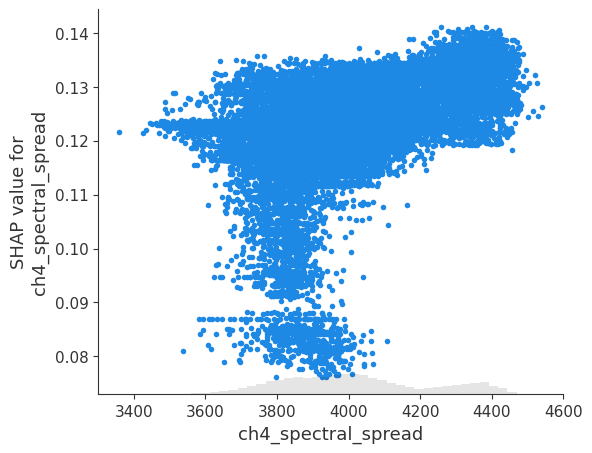

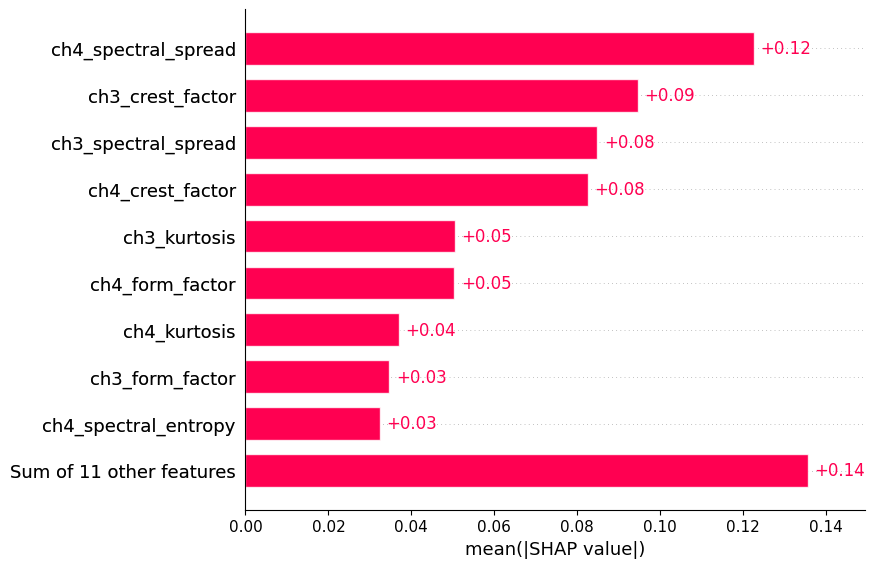

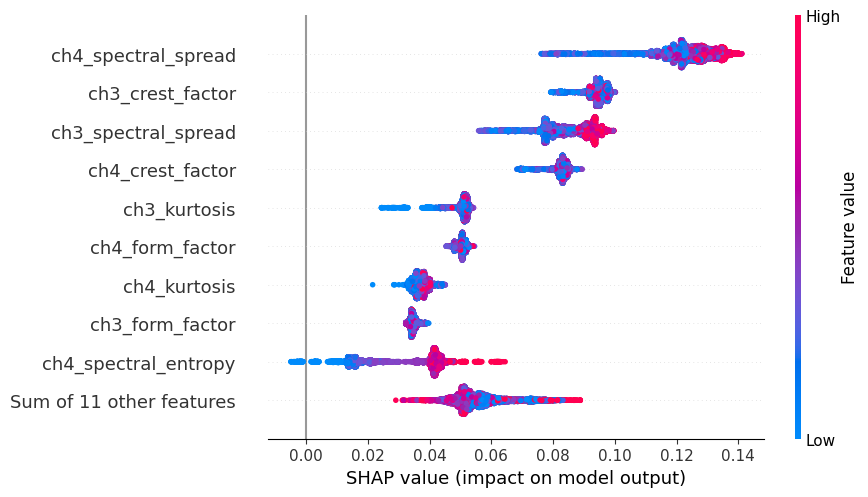

: 

: 

In [ ]:
import numpy as np

# 1. Выбираем класс (например, индекс 1)
class_idx = 3
shap_for_class = shap_values[:, :, class_idx]

# 2. Считаем среднюю важность (mean absolute SHAP) для каждого признака
mean_abs_shap = np.abs(shap_for_class).mean(axis=0)

# 3. Создаем DataFrame для удобной сортировки
feature_importance = pd.DataFrame({
    'feature': test_feature_names,
    'importance': mean_abs_shap
})

# 4. Сортируем и берем топ-5
top_5_features = feature_importance.sort_values(by='importance', ascending=False).head(5)

print(f"Топ-5 важных признаков для класса {class_idx}:")
print(top_5_features)

# 3. Находим индекс самого важного признака
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = test_feature_names[top_feature_idx]

print(f"Самый важный признак для класса {class_idx}: {top_feature_name}")

# 1. Создаем объект Explanation для конкретного класса (например, 1)
# Передаем: SHAP-значения класса, данные признаков и их имена
exp = shap.Explanation(
    values=shap_values[:, :, class_idx],      # Срез для нужного класса
    data=test_features,                        # Сами данные (X_test)
    feature_names=test_feature_names           # Имена колонок
)

# 2. Строим scatter plot (он по умолчанию добавит гистограмму сверху)
# Можно передать индекс признака (например, 0) или его имя строкой
shap.plots.scatter(exp[:, "ch4_spectral_spread"])

shap.plots.bar(exp)

shap.plots.beeswarm(exp)

shap.plots.heatmap(exp)

In [ ]:
# RMS for external dataset
rms_feat_df = features_df[['ch3_rms', 'ch4_rms']].copy()
meta_df = pd.DataFrame(win_metadata)[['class', 'load', 'electrical_frequency_hz', 'sample_id']].copy()
rms_df = pd.concat([meta_df, rms_feat_df], axis=1)
rms_df = rms_df.sort_values(by=['class', 'load', 'electrical_frequency_hz', 'sample_id']).reset_index(drop=True)
print(rms_df.head())

rms_df.to_excel(project_root / "vibro_rms_features.xlsx", index=False)

  class  load  electrical_frequency_hz sample_id   ch3_rms   ch4_rms
0    d0   0.0                       20      0001  0.001263  0.001725
1    d0   0.0                       20      0001  0.001336  0.001199
2    d0   0.0                       20      0001  0.001475  0.001195
3    d0   0.0                       20      0001  0.001227  0.001619
4    d0   0.0                       20      0001  0.001292  0.001252


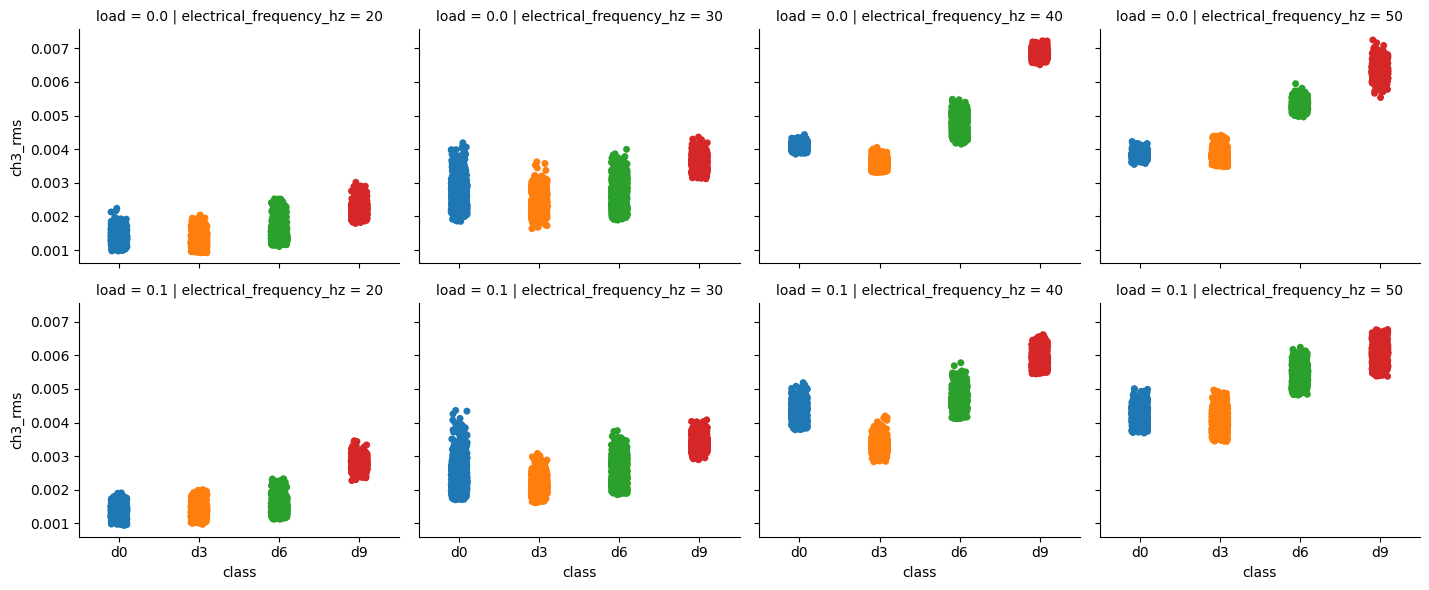

In [ ]:
import seaborn as sns
sns.catplot(
    data=rms_df, 
    x='class', 
    y='ch3_rms', 
    col='electrical_frequency_hz', # Speeds across the top
    row='load',                    # Loads down the side
    hue='class', 
    kind='strip',
    height=3,                      # Height of each sub-plot
    aspect=1.2                     # Width vs height ratio
)